In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points, split_domain_boundary
from utils import s2_uniform_grid_init, uniform_rand_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence

In [2]:
class ShallowReLUkNetwork:
    def __init__(self, ws, bs, train_pts, k=1, m1=1, m2=1):
        self.n = ws.shape[0]
        self.W = ws 
        self.b = bs
        self.k = k
        self.m1 = m1 
        self.m2 = m2
        pts_dom, pts_bd = split_domain_boundary(train_pts)
        self.pts_dom = pts_dom #.requires_grad_(True)
        self.pts_bd = pts_bd
    
    def feat_extract(self, x):
        return F.relu(x @ self.W.t() + self.b) ** self.k

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 
    
    def rhs(self, x):
        u = torch.sin(self.m1 * pi * x[:, 0:1]) * torch.sin(self.m2 * pi * x[:, 1:2])
        coeff = 1 + (self.m1 * pi) ** 2 + (self.m2 * pi) ** 2
        return coeff * u

    def lapfeat(self, x):
        """
        Analytic Laplacian of ReLU^k features
        x: (N, d)
        Returns: (N, m)
        """
        # pre-activation
        z = x @ self.W.t() + self.b    # (N, m)

        # mask for ReLU active region
        active = (z > 0).float()

        if self.k < 2:
            # Laplacian is identically zero if k=0 or 1
            return torch.zeros_like(z)

        # squared row norms of W: (m,)
        W_norm2 = (self.W**2).sum(dim=1)   # (m,)
        # expand to (N, m)
        W_norm2 = W_norm2.unsqueeze(0).expand_as(z)

        lap = self.k * (self.k - 1) * (z ** (self.k - 2)) * W_norm2 * active
        return lap

    def assemble(self):
        gs = self.feat_extract(self.pts_dom)
        lap_gs = self.lapfeat(self.pts_dom)
        A_dom = -lap_gs + gs
        b_dom = self.rhs(self.pts_dom)
        A_bd = self.feat_extract(self.pts_bd)
        b_bd = self.target(self.pts_bd)
        A = torch.concat([A_dom, A_bd])
        b = torch.concat([b_dom, b_bd])       
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()

In [2]:
class ShallowTanhFitter:
    def __init__(self, ws, bs, train_pts, m1=1, m2=1):
        self.n = ws.shape[0]
        self.W = ws
        self.b = bs
        self.m1 = m1
        self.m2 = m2
        self.pts = train_pts

    def feat_extract(self, x):
        # tanh activation
        return torch.tanh(x @ self.W.t() + self.b)

    def target(self, x):
        # same target as before
        z = torch.sin(self.m1 * pi * x[:, 0:1]) * torch.sin(self.m2 * pi * x[:, 1:2])
        return z

    def assemble(self):
        A = self.feat_extract(self.pts)
        b = self.target(self.pts)
        return A, b

    def solve(self):
        A, b = self.assemble()

        # scaling (same as your ReLU version)
        c = 100.0
        for i in range(len(A)):
            max_a = abs(A[i, :]).max()
            max_b = A[i, :].max()
            if max_a != max_b:
                ratio = -c / max_a
            else:
                ratio = c / max_a
            A[i, :] = A[i, :] * ratio
            b[i] = b[i] * ratio

        alpha = scipy.linalg.lstsq(A.numpy(), b.numpy())[0]
        self.alpha = torch.tensor(alpha, dtype=torch.float32)

    def forward(self, x):
        return self.feat_extract(x) @ self.alpha

    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()


num neuron : 11 - rel l2 : 9.5010e+00
num neuron : 23 - rel l2 : 4.4167e-01
num neuron : 43 - rel l2 : 9.7610e-02
num neuron : 69 - rel l2 : 2.6209e-02
num neuron : 125 - rel l2 : 9.9708e-03
num neuron : 239 - rel l2 : 2.1130e-03
num neuron : 457 - rel l2 : 7.0377e-04
num neuron : 909 - rel l2 : 4.9742e-05
num neuron : 1809 - rel l2 : 1.4188e-05


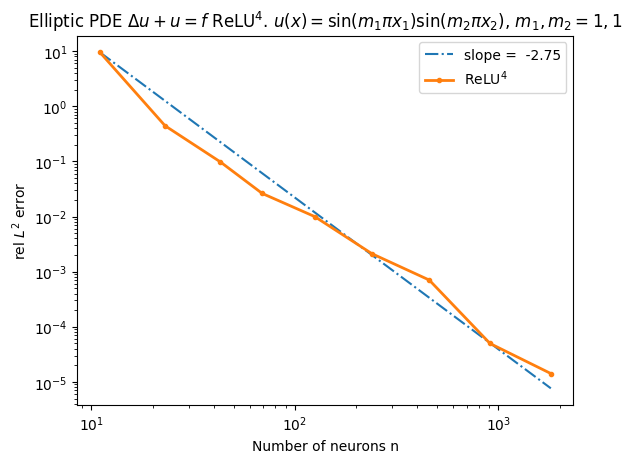

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
11 		 & 9.501e+00 &		 *  \\ \hline  

23 		 &  4.417e-01 &  		 4.16  \\ \hline  

43 		 &  9.761e-02 &  		 2.41  \\ \hline  

69 		 &  2.621e-02 &  		 2.78  \\ \hline  

125 		 &  9.971e-03 &  		 1.63  \\ \hline  

239 		 &  2.113e-03 &  		 2.39  \\ \hline  

457 		 &  7.038e-04 &  		 1.70  \\ \hline  

909 		 &  4.974e-05 &  		 3.85  \\ \hline  

1809 		 &  1.419e-05 &  		 1.82  \\ \hline  



In [4]:
x_train = SquareMesh2D_points(0,1,200)
x_test = SquareMesh2D_points(0,1,150)
k = 4
m1 = 1
m2 = 1
neuron_num_arr= np.array([2**i for i in range(4,13)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = ShallowReLUkNetwork(
        ws, bs, x_train, k=k, m1=m1, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n, rel_errl2))
title = "Elliptic PDE $\Delta u + u = f$ ReLU$^{}$. $u(x) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)
plot_err_convergence(k,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)

In [2]:
class ShallowTanhFitter:
    def __init__(self, ws, bs, train_pts, m1=1, m2=1):
        self.n = ws.shape[0]
        self.W = ws
        self.b = bs
        self.m1 = m1
        self.m2 = m2
        self.pts = train_pts

    def feat_extract(self, x):
        # tanh activation
        return torch.tanh(x @ self.W.t() + self.b)

    def target(self, x):
        # same target as before
        z = torch.sin(self.m1 * pi * x[:, 0:1]) * torch.sin(self.m2 * pi * x[:, 1:2])
        return z

    def assemble(self):
        A = self.feat_extract(self.pts)
        b = self.target(self.pts)
        return A, b

    def solve(self):
        A, b = self.assemble()

        # scaling (same as your ReLU version)
        c = 100.0
        for i in range(len(A)):
            max_a = abs(A[i, :]).max()
            max_b = A[i, :].max()
            if max_a != max_b:
                ratio = -c / max_a
            else:
                ratio = c / max_a
            A[i, :] = A[i, :] * ratio
            b[i] = b[i] * ratio

        alpha = scipy.linalg.lstsq(A.numpy(), b.numpy())[0]
        self.alpha = torch.tensor(alpha, dtype=torch.float32)

    def forward(self, x):
        return self.feat_extract(x) @ self.alpha

    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()


In [3]:
x_train = SquareMesh2D_points(0,1,200)
x_test = SquareMesh2D_points(0,1,150)
s = 4
m1 = 1
m2 = 1
neuron_num_arr= np.array([2**i for i in range(4,13)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = uniform_rand_init(n, s=s)
    model = ShallowTanhFitter(
        ws, bs, x_train, m1=m1, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n, rel_errl2))
title = "Elliptic PDE $\Delta u + u = f$ ReLU$^{}$. $u(x) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)
plot_err_convergence(s, 2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)

RuntimeError: expected m1 and m2 to have the same dtype, but got: double != float